In [1]:
import pandas as pd
import sqlite3

## Ex01
Нужно воссоздать график в точности как на примере (и по данным, и по стилю):
- Анализируй только пользователей, без админов.
- Учитывай только те даты, когда есть и просмотры, и коммиты из checker.
- Размер шрифта — 8.
- Размер фигуры — (15, 8).
- В конце блокнота добавь markdown-ячейку с вопросом: “Сколько раз число просмотров превышало 150?” и строкой: “Ответ ___”. Подставь число вместо подчёркивания.

In [2]:
db_path = '../data/checking-logs.sqlite'
conn = sqlite3.connect(db_path)

In [3]:
df = pd.io.sql.read_sql(
    """
    WITH v AS (
            SELECT DATE(datetime) AS date, COUNT(*) AS views
            FROM pageviews
            WHERE uid LIKE 'user_%'
            GROUP BY DATE(datetime)
        ),
        c AS (
            SELECT DATE(timestamp) AS date, COUNT(*) AS commits
            FROM checker
            WHERE uid LIKE 'user_%'
            GROUP BY DATE(timestamp)
        )
    SELECT v.date, v.views, c.commits
    FROM v
    JOIN c ON v.date = c.date
    ORDER BY v.date;
    """,
    conn,
    parse_dates=['date']
)

print('===Данные по просмотрам и коммитам===')
df

===Данные по просмотрам и коммитам===


,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


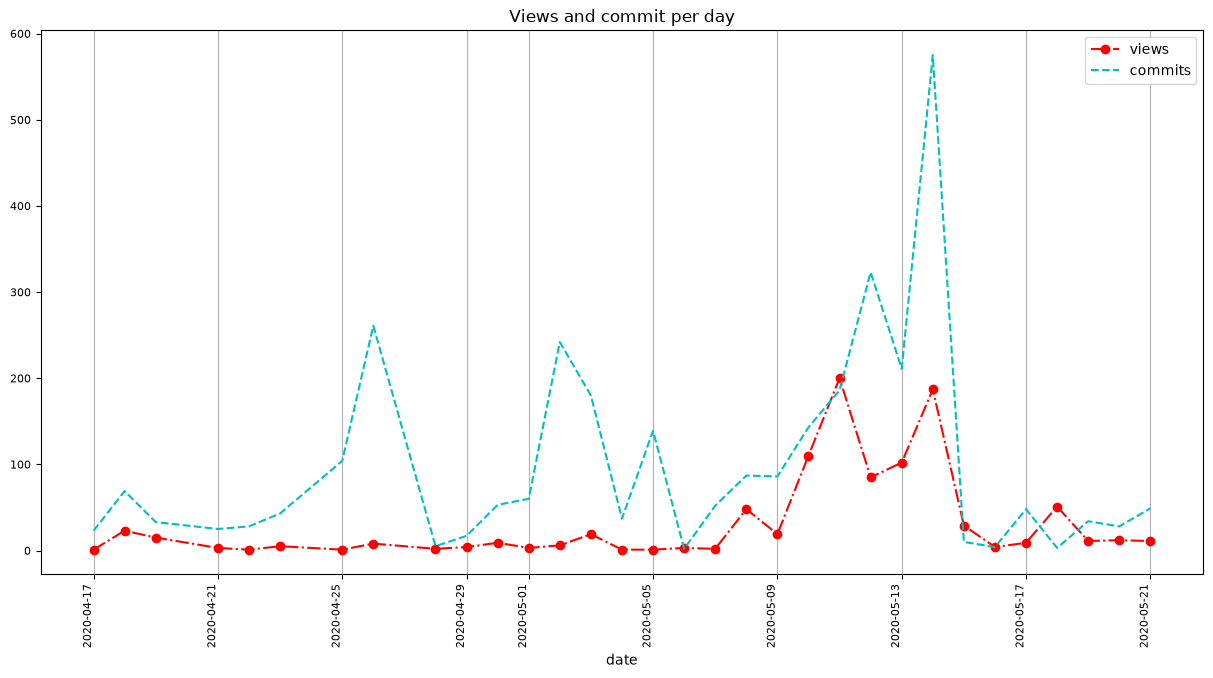

In [4]:
ax = df.plot(
    x='date',
    y=['views', 'commits'], 
    style=['-.o', '--'],
    color=['r','c'],
    figsize=(15, 8),
    rot=90,
    title='Views and commit per day',
    fontsize=8,
)
ax.grid(axis='x')

Сколько раз число просмотров превышало 150?

In [5]:
count = (df['views'] > 150).sum()
print(f'Ответ: {count}')

Ответ: 2


In [6]:
conn.close()